<a href="https://colab.research.google.com/github/244110601147-cmyk/pertemuan5-svm-naivebayes/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

# New Section

Library berhasil diimport!
Jumlah data: 20
                                        komentar sentimen
0    Alhamdulillah, ceramahnya sangat bermanfaat  positif
1               Materi ini mencerahkan hati saya  positif
2    Terima kasih ustadz, ilmunya sangat berguna  positif
3      Saya suka cara penyampaiannya yang santun  positif
4          Semoga Allah membalas kebaikan ustadz  positif
5    Ini ceramah terbaik yang pernah saya dengar  positif
6             Materinya dalam dan mudah dipahami  positif
7         Sangat menginspirasi, semoga istiqomah  positif
8  Kajiannya rutin saya ikuti, selalu bermanfaat  positif
9     Penyampaiannya jelas dan tidak membosankan  positif

Distribusi kelas:
 sentimen
positif    10
negatif    10
Name: count, dtype: int64
Jumlah fitur (kata unik) dari data training: 59
Contoh vocabulary: ['tidak', 'ada', 'contoh', 'praktis', 'hanya', 'teori', 'kontennya', 'relevan', 'dengan', 'kebutuhan']

=== NAÏVE BAYES FROM SCRATCH ===
Accuracy : 0.2500
F1-Score : 0.4

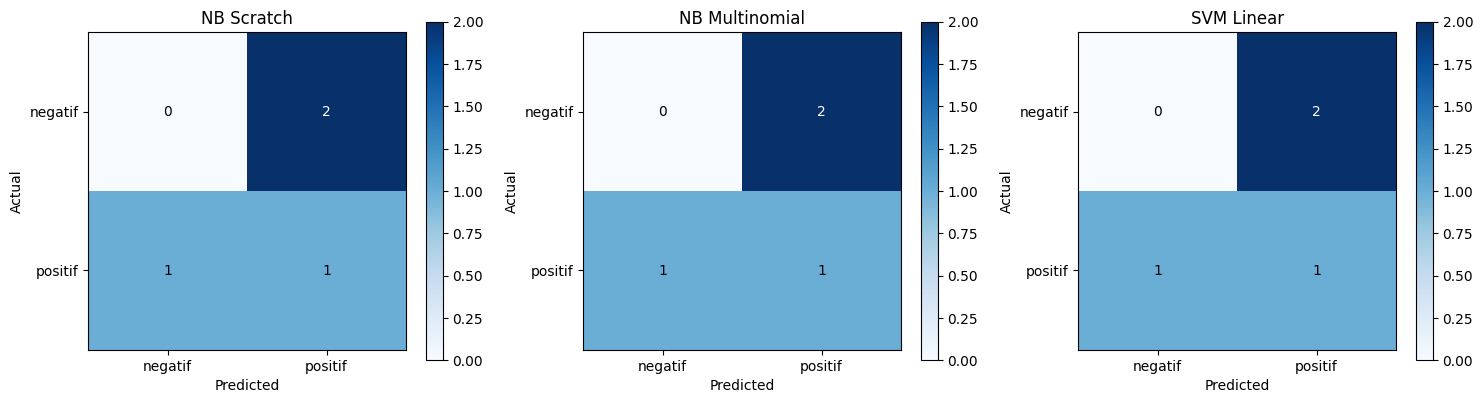

=== CROSS-VALIDATION (5-Fold) ===
NB Multinomial       | F1: 0.7933 ± 0.1890
NB Bernoulli         | F1: 0.7933 ± 0.1890
SVM Linear           | F1: 0.7867 ± 0.1067
SVM RBF              | F1: 0.6933 ± 0.1855
=== GRIDSEARCH SVM ===
Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score  : 0.7667
Test Accuracy  : 0.2500
Test F1-Score  : 0.4000
=== GRIDSEARCH NAÏVE BAYES ===
Best Alpha    : {'alpha': 0.01}
Best CV Score : 0.8667
Test Accuracy : 0.2500
=== PREDIKSI DATA BARU ===

Komentar: 'Alhamdulillah, kajiannya sangat bermanfaat dan menenangkan hati'
  Naïve Bayes: POSITIF
  SVM        : POSITIF

Komentar: 'Saya kecewa, materinya tidak sesuai dan membosankan'
  Naïve Bayes: NEGATIF
  SVM        : NEGATIF

Komentar: 'Penyampaian ustadz sangat jelas dan mudah dipahami'
  Naïve Bayes: POSITIF
  SVM        : POSITIF
=== KATA PALING INDIKATIF POSITIF ===
  saya: -2.3628
  semoga: -3.0535
  yang: -3.0535
  sangat: -3.0535
  penyampaiannya: -3.0535
  bermanfaat: -3.0535
 

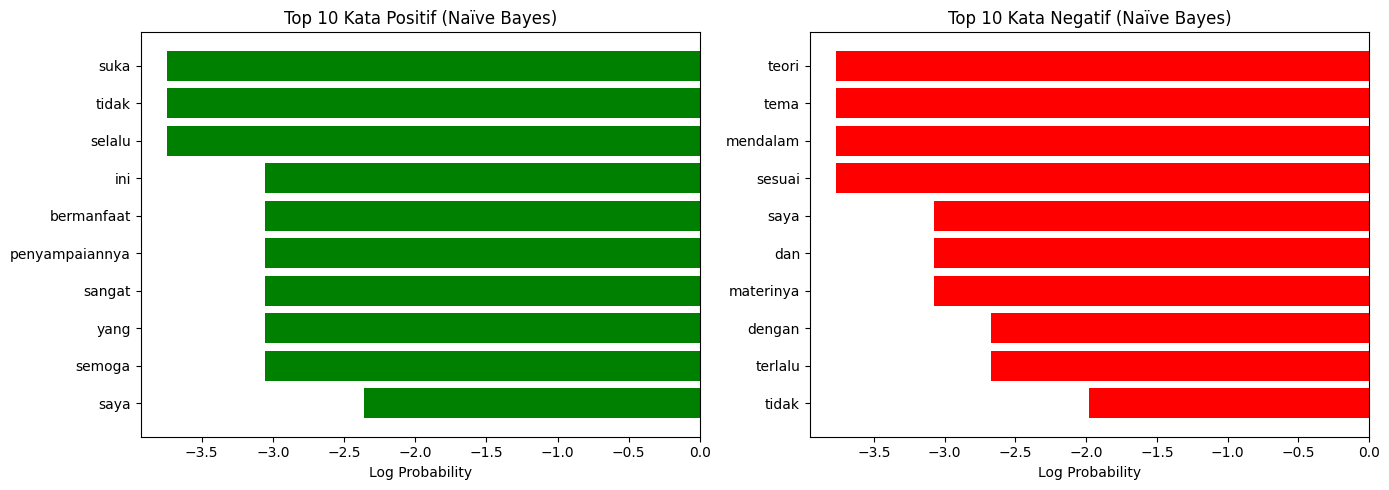

=== ANALISIS ERROR ===
Total error: 3 dari 4 data
Error rate: 75.00%

Contoh kesalahan prediksi:
  Komentar: Saya kecewa dengan penyampaiannya
  Aktual: negatif, Prediksi: positif
  Komentar: Suaranya kurang jelas, sulit didengar
  Aktual: negatif, Prediksi: positif
  Komentar: Materinya dalam dan mudah dipahami
  Aktual: positif, Prediksi: negatif


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 6)
print("Library berhasil diimport!")

# Dataset teks sederhana: komentar terhadap konten dakwah
data = {
    'komentar': [
        "Alhamdulillah, ceramahnya sangat bermanfaat",
        "Materi ini mencerahkan hati saya",
        "Terima kasih ustadz, ilmunya sangat berguna",
        "Saya suka cara penyampaiannya yang santun",
        "Semoga Allah membalas kebaikan ustadz",
        "Ini ceramah terbaik yang pernah saya dengar",
        "Materinya dalam dan mudah dipahami",
        "Sangat menginspirasi, semoga istiqomah",
        "Kajiannya rutin saya ikuti, selalu bermanfaat",
        "Penyampaiannya jelas dan tidak membosankan",
        "Ceramahnya terlalu panjang dan membosankan",
        "Materinya tidak sesuai dengan tema",
        "Saya tidak paham dengan penjelasannya",
        "Suaranya kurang jelas, sulit didengar",
        "Terlalu banyak basa-basi, tidak fokus",
        "Kontennya tidak relevan dengan kebutuhan saya",
        "Saya kecewa dengan penyampaiannya",
        "Materinya dangkal dan tidak mendalam",
        "Waktunya terlalu lama, membuat ngantuk",
        "Tidak ada contoh praktis, hanya teori"
    ],
    'sentimen': [
        'positif', 'positif', 'positif', 'positif', 'positif',
        'positif', 'positif', 'positif', 'positif', 'positif',
        'negatif', 'negatif', 'negatif', 'negatif', 'negatif',
        'negatif', 'negatif', 'negatif', 'negatif', 'negatif'
    ]
}
df = pd.DataFrame(data)
print("Jumlah data:", len(df))
print(df.head(10))
print("\nDistribusi kelas:\n", df['sentimen'].value_counts())

# ==================== NAÏVE BAYES FROM SCRATCH ====================

class NaiveBayesScratch:
    def __init__(self, alpha=1.0):
        self.alpha = alpha  # Laplace smoothing
        self.classes = None
        self.prior = {}
        self.likelihood = {}
        self.vocab = None

    def fit(self, X, y):
        """
        X: matriks count/fitur (n_samples, n_features)
        y: label (n_samples,)
        """
        self.classes = np.unique(y)
        n_samples, n_features = X.shape

        # Hitung prior
        for c in self.classes:
            self.prior[c] = np.sum(y == c) / n_samples

        # Hitung likelihood per fitur
        for c in self.classes:
            X_c = X[y == c]
            # P(x_i = 1 | c) dengan Laplace smoothing
            count_1 = np.sum(X_c, axis=0)
            # Corrected line: use count_1 (array) in the numerator
            prob_1 = (count_1 + self.alpha) / (len(X_c) + 2 * self.alpha)
            self.likelihood[c] = prob_1

    def predict(self, X):
        predictions = []
        for x in X:
            posteriors = {}
            for c in self.classes:
                # Log posterior untuk menghindari underflow
                log_posterior = np.log(self.prior[c])
                for i, xi in enumerate(x):
                    p = self.likelihood[c][i]
                    if xi > 0:
                        log_posterior += xi * np.log(p)
                posteriors[c] = log_posterior
            predictions.append(max(posteriors, key=posteriors.get))
        return np.array(predictions)

    def predict_proba(self, X):
        """Return probabilitas posterior (softmax dari log posterior)."""
        probas = []
        for x in X:
            log_posteriors = {}
            for c in self.classes:
                log_posterior = np.log(self.prior[c])
                for i, xi in enumerate(x):
                    p = self.likelihood[c][i]
                    if xi > 0:
                        log_posterior += xi * np.log(p)
                log_posteriors[c] = log_posterior

            # Softmax
            max_log = max(log_posteriors.values())
            exp_vals = {c: np.exp(lp - max_log) for c, lp in log_posteriors.items()}
            total = sum(exp_vals.values())
            probas.append([exp_vals[c]/total for c in self.classes])
        return np.array(probas)

# ==================== UJI NAÏVE BAYES FROM SCRATCH ====================

# Vectorize teks dengan CountVectorizer
# Use a dedicated vectorizer for training/testing and new predictions
train_vectorizer = CountVectorizer()
y = df['sentimen'].values

# Split data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['komentar'].values, y, test_size=0.2, random_state=42, stratify=y
)

# Fit train_vectorizer only on training data
X_train = train_vectorizer.fit_transform(X_train_raw).toarray()
X_test = train_vectorizer.transform(X_test_raw).toarray()

print(f"Jumlah fitur (kata unik) dari data training: {X_train.shape[1]}")
print(f"Contoh vocabulary: {list(train_vectorizer.vocabulary_.keys())[:10]}")

# Training Naïve Bayes from scratch
nb_scratch = NaiveBayesScratch(alpha=1.0)
nb_scratch.fit(X_train, y_train)
y_pred_nb_scratch = nb_scratch.predict(X_test)

print("\n=== NAÏVE BAYES FROM SCRATCH ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_nb_scratch):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_nb_scratch, pos_label='positif'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb_scratch))


# ==================== SVM DENGAN SCIKIT-LEARN ====================

# SVM Linear
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_svm_linear = svm_linear.predict(X_test)

# SVM RBF
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train, y_train)
y_pred_svm_rbf = svm_rbf.predict(X_test)

print("=== SVM LINEAR ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_svm_linear):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_svm_linear, pos_label='positif'):.4f}")

print("\n=== SVM RBF ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_svm_rbf):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_svm_rbf, pos_label='positif'):.4f}")


# ==================== PERBANDINGAN LENGKAP ====================

# Naïve Bayes scikit-learn (MultinomialNB)
nb_sk = MultinomialNB(alpha=1.0)
nb_sk.fit(X_train, y_train)
y_pred_nb_sk = nb_sk.predict(X_test)

# Naïve Bayes Bernoulli
nb_bernoulli = BernoulliNB(alpha=1.0)
nb_bernoulli.fit(X_train, y_train)
y_pred_nb_bernoulli = nb_bernoulli.predict(X_test)

# Tabel perbandingan
results = pd.DataFrame({
    'Model': ['NB Scratch', 'NB Multinomial', 'NB Bernoulli', 'SVM Linear', 'SVM RBF'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb_scratch),
        accuracy_score(y_test, y_pred_nb_sk),
        accuracy_score(y_test, y_pred_nb_bernoulli),
        accuracy_score(y_test, y_pred_svm_linear),
        accuracy_score(y_test, y_pred_svm_rbf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_nb_scratch, pos_label='positif'),
        f1_score(y_test, y_pred_nb_sk, pos_label='positif'),
        f1_score(y_test, y_pred_nb_bernoulli, pos_label='positif'),
        f1_score(y_test, y_pred_svm_linear, pos_label='positif'),
        f1_score(y_test, y_pred_svm_rbf, pos_label='positif')
    ]
})
print("=== PERBANDINGAN MODEL ===")
print(results.to_string(index=False))


# ==================== CONFUSION MATRIX ====================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ('NB Scratch', y_pred_nb_scratch),
    ('NB Multinomial', y_pred_nb_sk),
    ('SVM Linear', y_pred_svm_linear)
]

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred, labels=['negatif', 'positif'])
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['negatif', 'positif'])
    ax.set_yticklabels(['negatif', 'positif'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


# ==================== CROSS-VALIDATION ====================

models_cv = {
    'NB Multinomial': MultinomialNB(alpha=1.0),
    'NB Bernoulli': BernoulliNB(alpha=1.0),
    'SVM Linear': SVC(kernel='linear', C=1.0, random_state=42),
    'SVM RBF': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
}

print("=== CROSS-VALIDATION (5-Fold) ===")
# Use a separate vectorizer for cross-validation on the full dataset to avoid conflicts
cv_vectorizer = CountVectorizer()
X_all_cv = cv_vectorizer.fit_transform(df['komentar']).toarray()
for name, model in models_cv.items():
    scores = cross_val_score(model, X_all_cv, y, cv=5, scoring='f1_weighted')
    print(f"{name:20s} | F1: {scores.mean():.4f} \u00b1 {scores.std():.4f}")


# ==================== GRIDSEARCH SVM ====================

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

grid_svm.fit(X_train, y_train)

print("=== GRIDSEARCH SVM ===")
print(f"Best Parameters: {grid_svm.best_params_}")
print(f"Best CV Score  : {grid_svm.best_score_:.4f}")

# Evaluasi pada test set
y_pred_svm_best = grid_svm.best_estimator_.predict(X_test)
print(f"Test Accuracy  : {accuracy_score(y_test, y_pred_svm_best):.4f}")
print(f"Test F1-Score  : {f1_score(y_test, y_pred_svm_best, pos_label='positif'):.4f}")


# ==================== GRIDSEARCH NAÏVE BAYES ====================

param_grid_nb = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
}

grid_nb = GridSearchCV(
    MultinomialNB(),
    param_grid_nb,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_nb.fit(X_train, y_train)

print("=== GRIDSEARCH NAÏVE BAYES ===")
print(f"Best Alpha    : {grid_nb.best_params_}")
print(f"Best CV Score : {grid_nb.best_score_:.4f}")

y_pred_nb_best = grid_nb.best_estimator_.predict(X_test)
print(f"Test Accuracy : {accuracy_score(y_test, y_pred_nb_best):.4f}")


# ==================== PREDIKSI DATA BARU ====================

# Data komentar baru
komentar_baru = [
    "Alhamdulillah, kajiannya sangat bermanfaat dan menenangkan hati",
    "Saya kecewa, materinya tidak sesuai dan membosankan",
    "Penyampaian ustadz sangat jelas dan mudah dipahami"
]

# Vectorize using the same vectorizer fitted on training data
X_new = train_vectorizer.transform(komentar_baru).toarray()

# Prediksi dengan model terbaik
pred_nb = grid_nb.best_estimator_.predict(X_new)
pred_svm = grid_svm.best_estimator_.predict(X_new)

print("=== PREDIKSI DATA BARU ===")
for komentar, nb, svm in zip(komentar_baru, pred_nb, pred_svm):
    print(f"\nKomentar: '{komentar}'")
    print(f"  Naïve Bayes: {nb.upper()}")
    print(f"  SVM        : {svm.upper()}")


# ==================== FEATURE IMPORTANCE NAÏVE BAYES ====================

# Log probabilities untuk kelas positif dan negatif
feature_names = train_vectorizer.get_feature_names_out()
log_prob_pos = grid_nb.best_estimator_.feature_log_prob_[1]  # positif
log_prob_neg = grid_nb.best_estimator_.feature_log_prob_[0]  # negatif

# Kata yang paling mengindikasikan positif/negatif
top_pos = np.argsort(log_prob_pos)[-10:][::-1]
top_neg = np.argsort(log_prob_neg)[-10:][::-1]

print("=== KATA PALING INDIKATIF POSITIF ===")
for idx in top_pos:
    print(f"  {feature_names[idx]}: {log_prob_pos[idx]:.4f}")

print("\n=== KATA PALING INDIKATIF NEGATIF ===")
for idx in top_neg:
    print(f"  {feature_names[idx]}: {log_prob_neg[idx]:.4f}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh([feature_names[i] for i in top_pos], [log_prob_pos[i] for i in top_pos], color='green')
axes[0].set_title('Top 10 Kata Positif (Naïve Bayes)')
axes[0].set_xlabel('Log Probability')

axes[1].barh([feature_names[i] for i in top_neg], [log_prob_neg[i] for i in top_neg], color='red')
axes[1].set_title('Top 10 Kata Negatif (Naïve Bayes)')
axes[1].set_xlabel('Log Probability')

plt.tight_layout()
plt.show()


# ==================== ANALISIS ERROR ====================

# Prediksi pada data test dengan model terbaik
y_pred_final = grid_svm.best_estimator_.predict(X_test)

# Identifikasi kesalahan
errors = y_test != y_pred_final
error_indices = np.where(errors)[0]

print("=== ANALISIS ERROR ===")
print(f"Total error: {len(error_indices)} dari {len(y_test)} data")
print(f"Error rate: {len(error_indices)/len(y_test)*100:.2f}%")

# Tampilkan contoh kesalahan
if len(error_indices) > 0:
    print("\nContoh kesalahan prediksi:")
    for idx in error_indices[:5]:
        print(f"  Komentar: {X_test_raw[idx]}")
        print(f"  Aktual: {y_test[idx]}, Prediksi: {y_pred_final[idx]}")
else:
    print("Tidak terdapat kesalahan prediksi pada test set.")


# ==================== COMMIT & PUSH ====================

# Simpan notebook terlebih dahulu (File → Save)
# Lalu jalankan perintah terminal berikut jika menggunakan Google Colab:
# !git add .
# !git commit -m "Praktikum SVM & Naïve Bayes: implementasi from scratch + tuning"
# !git push origin main
